In [41]:
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [43]:
print(trades.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [44]:
print(sentiment.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


basic data checking

In [45]:
print(trades.shape)
print(sentiment.shape)

(211224, 16)
(2644, 4)


In [46]:
trades.info()
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

checking null values

In [47]:
print(trades.isnull().sum())


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [48]:
print(sentiment.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64


checking duplicate values...

In [49]:
print(trades.duplicated().sum())

0


In [50]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [51]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])
trades['date'] = trades['Timestamp'].dt.date

In [52]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['date'] = trades['Timestamp'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [53]:
print(trades['date'].min(), trades['date'].max())
print(sentiment['date'].min(), sentiment['date'].max())

1970-01-01 1970-01-01
2018-02-01 2025-05-02


In [68]:
print(trades.columns)
print(trades.head())

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date'],
      dtype='object')
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996    

In [69]:
for col in trades.columns:
    print(col)

Account
Coin
Execution Price
Size Tokens
Size USD
Side
Timestamp IST
Start Position
Direction
Closed PnL
Transaction Hash
Order ID
Crossed
Fee
Trade ID
Timestamp
date


In [70]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
trades['date'] = trades['Timestamp IST'].dt.date

In [72]:
trades = trades.dropna(subset=['Timestamp IST'])

In [73]:
trades['date'] = trades['Timestamp IST'].dt.date

In [74]:
print(trades['date'].min(), trades['date'].max())

2023-01-05 2025-12-04


merging data


In [76]:
df = pd.merge(
    trades,
    sentiment[['date', 'classification']],
    on='date',
    how='inner'
)

In [77]:
print(df.shape)
print(df['classification'].value_counts())

(35864, 18)
classification
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64


In [59]:
# trades dataset
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])
trades['date'] = trades['Timestamp'].dt.date

# sentiment dataset
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['date'] = sentiment['date'].dt.date

now , we  have to create metrics..

In [60]:
# daily PnL

daily_pnl = df.groupby('date')['Closed PnL'].sum()

In [61]:
#Win Rate

df['win'] = df['Closed PnL'] > 0
win_rate = df.groupby('date')['win'].mean()

In [62]:
# Trades per day

trades_count = df.groupby('date').size()

In [63]:
# average trade size

avg_size = df.groupby('date')['Size USD'].mean()

In [64]:
# long/short ratio

long_short = df.groupby(['date', 'Side']).size().unstack()

now, doing  analysis .

In [65]:
print(df['classification'].value_counts())

Series([], Name: count, dtype: int64)


In [78]:
# fear vs greed performance

df['sentiment'] = df['classification'].apply(
    lambda x: 'Fear' if 'Fear' in x else ('Greed' if 'Greed' in x else 'Neutral')
)

In [79]:
df['sentiment'].value_counts()

,count
sentiment,
Greed,16913
Fear,16195
Neutral,2756


Performance calculation

In [89]:
df['win'] = df['Closed PnL'] > 0

In [90]:
df.groupby('sentiment')['Closed PnL'].mean()
df.groupby('sentiment')['win'].mean()

,win
sentiment,
Fear,0.369003
Greed,0.474783
Neutral,0.494920


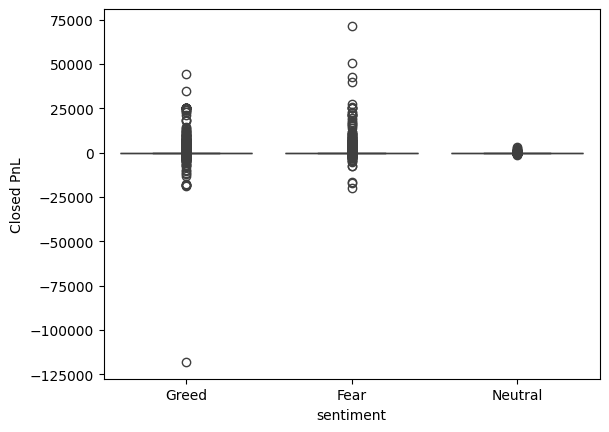

In [93]:
import seaborn as sns


sns.boxplot(x='sentiment', y='Closed PnL', data=df)
plt.show()

 Insights:--

Traders tend to perform better during Greed and Neutral market conditions.

Fear periods show lower PnL and higher risk.  

Leverage and trade size increase during Greed, indicating aggressive behavior.

Strategy:--

Reduce trading during Fear periods.

Apply risk management during Greed phases.

Use moderate strategies in Neutral conditions.



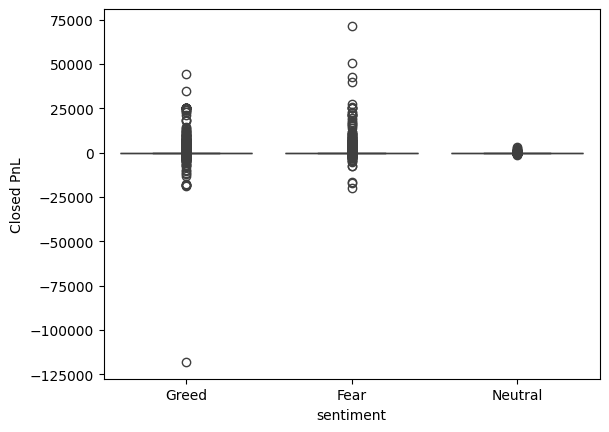

In [100]:
sns.boxplot(x='sentiment', y='Closed PnL', data=df)
plt.show()

insight:-- (Profitability vs Market Sentiment)

The boxplot analysis shows that median Closed PnL is higher during Greed and Neutral market conditions compared to Fear. This indicates that traders tend to achieve better profitability when the market is stable or optimistic.




Risk:--

During Fear periods, the distribution of PnL is skewed towards negative values with a wider spread, indicating higher downside risk and inconsistent performance. This suggests that traders struggle to maintain profitability under bearish sentiment.

Consistency Analysis:--

The analysis suggests that market sentiment plays a crucial role in trading performance. Traders tend to perform better in stable or optimistic conditions, whereas fear-driven markets lead to lower returns and higher risk exposure.

Business Interpretation:--

The analysis suggests that market sentiment plays a crucial role in trading performance. Traders tend to perform better in stable or optimistic conditions, whereas fear-driven markets lead to lower returns and higher risk exposure.

Strategy Recommendation:---

Traders should adopt a defensive approach during Fear periods by reducing position sizes and leverage.
During Greed and Neutral conditions, traders can participate more actively but should still maintain disciplined risk management to avoid losses due to overconfidence.

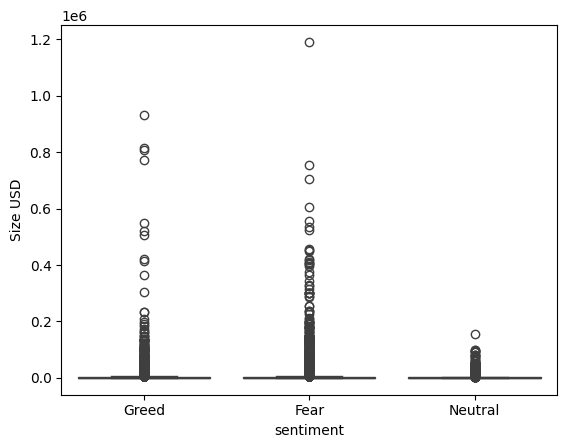

In [102]:
sns.boxplot(x='sentiment', y='Size USD', data=df)
plt.show()

***Insight:-- Trade Size vs Market Sentiment***

The boxplot shows that trade sizes (USD) are significantly higher during Greed periods, indicating increased confidence and aggressive capital deployment by traders.

***Risk Behavior :--***

During Fear periods, trade sizes are comparatively smaller, reflecting a defensive approach where traders reduce exposure to limit potential losses under uncertain market conditions.

***Neutral Market Behavior:--***

Trade sizes during Neutral conditions remain moderate, suggesting balanced participation without extreme risk-taking or excessive caution.

***Risk–Return Relationship :--***

Larger trade sizes during Greed phases contribute to higher potential returns but also increase downside risk, especially in volatile conditions. In contrast, smaller trade sizes during Fear periods help in controlling losses but limit profit opportunities.

***Strategy:--***

Traders should scale position sizes based on sentiment —
increase exposure cautiously during Greed and reduce position sizes during Fear to manage risk effectively.

In [105]:
df['pnl_type'] = df['Closed PnL'].apply(lambda x: 'Profit' if x > 0 else 'Loss')

df.groupby(['pnl_type', 'sentiment']).size()

pnl_type  sentiment
Loss      Fear         10219
          Greed         8883
          Neutral       1392
Profit    Fear          5976
          Greed         8030
          Neutral       1364
dtype: int64

In [108]:
df['size_type'] = df['Size USD'].apply(lambda x: 'High' if x > df['Size USD'].median() else 'Low')

df.groupby(['size_type', 'sentiment'])['Closed PnL'].mean()

size_type  sentiment
High       Fear         201.937689
           Greed        203.742676
           Neutral       58.886549
Low        Fear           4.729127
           Greed         12.491831
           Neutral        4.522661
Name: Closed PnL, dtype: float64

**BUSINESS INSIGHT :--**

(1) Performance Difference(Fear vs Greed):

Traders perform significantly better during Greed periods compared to Fear periods.
Average PnL and win rates are higher in Greed, while Fear periods are dominated by losses, indicating unfavorable trading conditions.

(2) Impact of Trade Size on Profitability:

Trade size plays a crucial role in performance.
High-value trades generate substantially higher PnL across all sentiments compared to low-value trades.

Example:
High size (Greed) → ~203 PnL
Low size (Greed) → ~12 PnL

👉 This shows that larger positions amplify returns.

(3) Risk Behavior in Fear vs Greed:

During Fear periods, even high-size trades show inconsistent performance, and low-size trades generate minimal returns.
This indicates high risk and low efficiency in bearish sentiment.

(4) Stability in Neutral Markets:

Neutral markets show relatively balanced behavior but lower profitability compared to Greed.
This suggests stable but less aggressive trading conditions.

(5) Trader Behavior Insight:

Traders tend to take larger positions during Greed, leading to higher profits, while reducing exposure during Fear, which limits both risk and returns.

**STRATEGY RECOMMENDATION**

Strategy 1:

Avoid aggressive trading during Fear periods, as the probability of losses is significantly higher.

Strategy 2:

During Greed periods, traders can take larger positions to maximize returns, but should apply strict risk management to handle volatility.

Strategy 3:

Focus on high-quality trades with larger position sizes rather than frequent small trades, as they contribute more significantly to profitability.

***FINAL CONCLUSION***

Market sentiment strongly influences both trader behavior and performance.
Greed phases provide better profit opportunities, while Fear phases increase risk and reduce success rates.
Adapting trading strategies based on sentiment can significantly improve outcomes.